In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

In [24]:
def caluc_pixels(image, contour):
  """
  Extract pixel values inside a contour region.

  Creates a binary mask from the given contour, selects all pixels
  belonging to the object, and converts them to float32 format for
  further processing such as K-Means clustering.
  """
  mask = np.zeros(image.shape[:2], dtype="uint8")
  cv.drawContours(mask, [contour], -1, 255, -1)
  pixels = image[mask == 255]
  pixels = np.float32(pixels)
  return pixels

In [25]:
def color_dominant(pixels):
  """
    Find dominant colors in a set of pixels using K-Means clustering.

    Clusters the input pixels into K color groups, calculates the
    percentage of pixels belonging to each cluster, and returns
    the cluster centers sorted by dominance.

    Returns:
        dominant (ndarray): Color centers sorted from most dominant
                            to least dominant.
        percentage (ndarray): Percentage of pixels for each color cluster.
  """
  k = 3
  criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 200, 0.1)
  ret, label, center = cv.kmeans(pixels, k, None, criteria, 20, cv.KMEANS_PP_CENTERS)

  count = np.bincount(label.flatten())
  precentage = count / count.sum()
  idx = np.argsort(precentage)[:: -1]
  center = np.uint8(center)
  dominant = center[idx]
  precentage[idx]
  return dominant, precentage

In [26]:
def plate(dominant, precentage, shape):
  """
    Visualize dominant colors as a color palette.

    Creates a horizontal color bar where each segment represents
    a dominant color and its width corresponds to the percentage
    of pixels belonging to that color cluster.

    Args:
        dominant (ndarray): Dominant color centers returned by K-Means.
        precentage (ndarray): Percentage of each color cluster.
        shape (str): Object name used as the palette title.
  """
  plate = np.zeros((100, 500, 3), dtype = np.uint8)

  w = 0
  for color, precent in zip(dominant, precentage):
    # Ensure precent is an integer for slicing, or convert to width
    width = int(precent * 500) # Scale percentage to total width of 500
    plate[:, w : w + width] = color
    w = w + width

  plt.figure(figsize = (7, 3))
  plt.title(shape)
  plt.imshow(cv.cvtColor(plate, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

In [27]:
def detected_shape(approx):
  """
    Classify a quadrilateral based on its side lengths and angles.

    Analyzes the vertices obtained from contour approximation to
    determine whether the shape is a square, rectangle, rhombus,
    or an unknown quadrilateral.

    Returns:
        str: Detected shape name.
  """
  points = approx.reshape(4, 2)
  A = points[0]
  B = points[1]
  C = points[2]
  D = points[3]

  AB = np.linalg.norm(A - B)
  BC = np.linalg.norm(B - C)
  CD = np.linalg.norm(C - D)
  DA = np.linalg.norm(D - A)

  angle_A = np.dot(A, B)
  right_angle = abs(angle_A - 90) < 5
  equal_side = (
      abs(AB - BC) < 5 and
      abs(BC - CD) < 5 and
      abs(CD - DA) < 5 and
      abs(DA - AB) < 5
  )

  if equal_side:
    if right_angle:
      return "Square"
    else:
      return "rhombus"
  else:
    if right_angle:
      return "Rectangle"
    else:
      return "Unknown"

In [28]:
def detected_shapes(contour):
  """
    Detect the geometric shape of a contour.

    Approximates the contour as a polygon and classifies the object
    based on the number of vertices. Quadrilaterals are further
    analyzed to distinguish between square, rectangle, and rhombus.

    Returns:
        str: Detected shape name.
  """
  approx = cv.approxPolyDP(contour, 0.03 * cv.arcLength(contour, True), True)
  shape = "undefined"

  if len(approx) == 3:
        shape = "Triangle"
  elif len(approx) == 4:
        shape = detected_shape(approx)
  elif len(approx) == 5:
        shape = "Pentagon"
  elif len(approx) == 6:
        shape = "Hexagon"
  elif len(approx) >= 7:
        shape = "Circle"
  else:
        shape = "Unknown"

  return shape

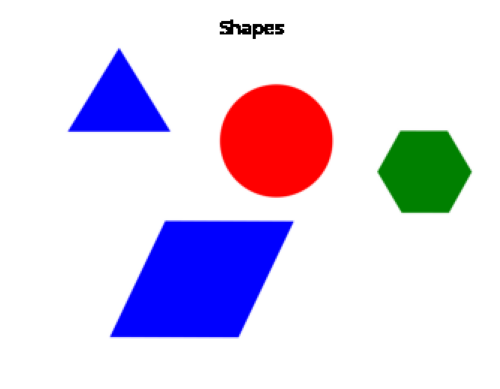

Unknown


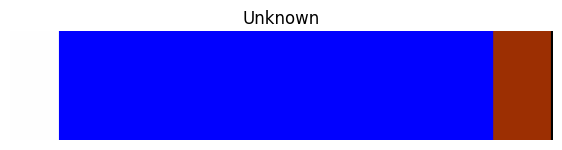

rhombus


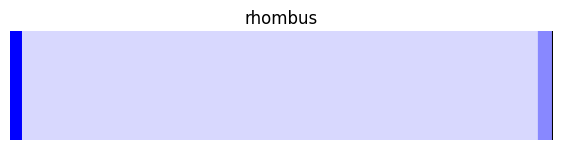

Hexagon


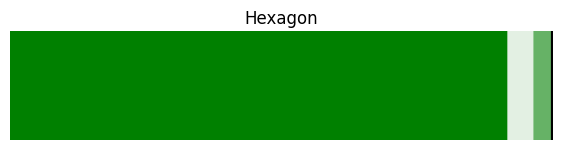

Circle


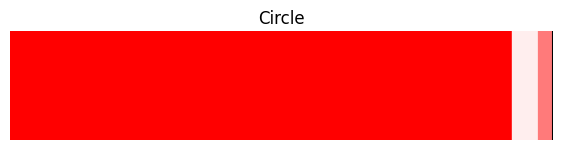

Triangle


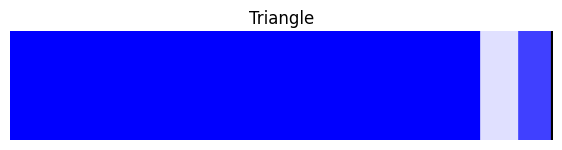

Unknown


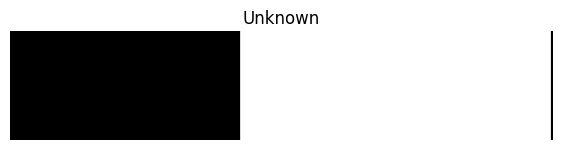

In [30]:
# Shape and dominant color analysis pipeline.
#
# This workflow detects object contours, classifies geometric shapes,
# extracts object pixels using masks, applies K-Means clustering to
# identify dominant colors, and visualizes the color distribution of
# each detected object.
image = cv.imread("/content/drive/MyDrive/Colab Notebooks/Image/shapes.png")
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
# Detect geometric shapes and analyze their dominant colors
# using contour extraction and K-Means clustering.
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
imshow(image= image)
blur = cv.GaussianBlur(gray, (7, 7), 0)
ret, thresh = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
contours, _ = cv.findContours(thresh, cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)

for contour in contours:
  if cv.contourArea(contour) < 100:
        continue
  shape = detected_shapes(contour)
  print(shape)
  pixels = caluc_pixels(image, contour)
  dominant, precentage = color_dominant(pixels)
  plate(dominant, precentage, shape)
